torch.Size([2, 128]) torch.Size([2, 128])
torch.Size([2, 1])


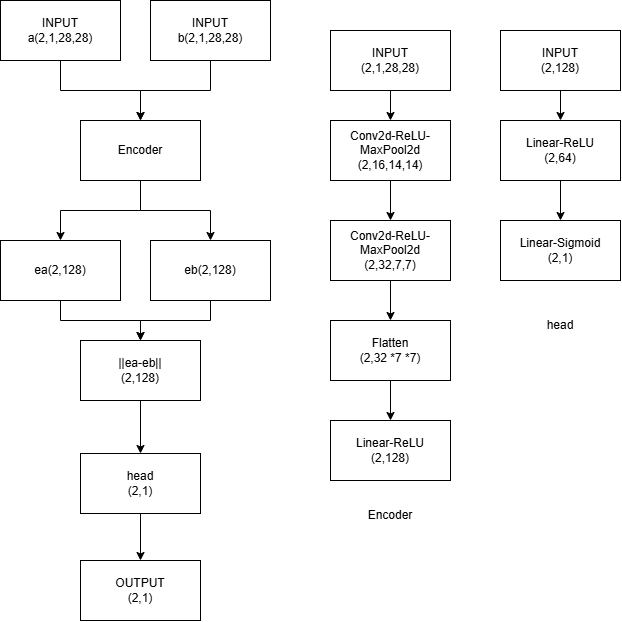

In [12]:
import torch
import torch.nn as nn
class SiameseNet(nn.Module):
    class Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.feat = nn.Sequential(
                nn.Conv2d(1,16,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
                nn.Conv2d(16,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
                nn.Flatten(),
                nn.Linear(32 * 7 * 7,128),nn.ReLU(),
            )
        def forward(self,x):
            return self.feat(x)
    def __init__(self):
        super().__init__()
        self.encoder = self.Encoder()
        self.head = nn.Sequential(
            nn.Linear(128,64),nn.ReLU(),
            nn.Linear(64,1),nn.Sigmoid(),
        )
    def forward(self,a,b):
        ea,eb = self.encoder(a),self.encoder(b)
        print(ea.shape,eb.shape)
        return self.head(torch.abs(ea-eb))
model = SiameseNet()
model.eval()
with torch.no_grad():
    out = model(torch.randn(2,1,28,28),torch.randn(2,1,28,28))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('SiameseNET.png')
display.display(img) 